# Ablative Study Preprocessing , 2 Datasets

Downloads datasets from Kaggle, converts to grayscale 224×224 tensors normalised to [0, 1],
splits into train/val/test, and saves `.pt` files ready for training.

| Dataset | Classes | Source |
|---------|---------|--------|
| 2 | 4 (glioma, meningioma, pituitary, no_tumor) | masoudnickparvar/brain-tumor-mri-dataset |
| 3 | 44 | fernando2rad/brain-tumor-mri-images-44c |

## 1. Setup

In [1]:
!pip install kaggle numpy pillow tqdm scikit-learn torch matplotlib --quiet

In [2]:
import os, json, shutil
import numpy as np
import torch
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
from tqdm import tqdm
from sklearn.model_selection import train_test_split

try:
    from google.colab import userdata, drive
    ON_COLAB = True
except ImportError:
    ON_COLAB = False

SEED = 42
print(f'Running on {"Google Colab" if ON_COLAB else "local environment"}')

Running on local environment


In [3]:
if ON_COLAB:
    drive.mount('/content/drive')
    DATA_DIR   = Path('/content')
    OUTPUT_DIR = Path('/content/drive/MyDrive/brain_mri_preprocessed')
else:
    # Local Paths 
    DATA_DIR   = Path('./data')
    OUTPUT_DIR = Path('./brain_mri_preprocessed')

DATA_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f'Data dir  : {DATA_DIR}')
print(f'Output dir: {OUTPUT_DIR}')

Data dir  : data
Output dir: brain_mri_preprocessed


## 2. Kaggle Credentials & Download

**Colab**: reads `KAGGLE_USERNAME` and `KAGGLE_KEY` from Colab Secrets (Secrets panel → add keys).

**Local**: place your `kaggle.json` at `~/.kaggle/kaggle.json` — the Kaggle CLI will find it automatically.
Download from: kaggle.com → Account → API → Create New Token.

In [4]:
if ON_COLAB:
    # Read credentials from Colab Secrets — key never appears in the notebook
    kaggle_username = userdata.get('KAGGLE_USERNAME')
    kaggle_key      = userdata.get('KAGGLE_KEY')
    os.makedirs('/root/.kaggle', exist_ok=True)
    with open('/root/.kaggle/kaggle.json', 'w') as f:
        json.dump({'username': kaggle_username, 'key': kaggle_key}, f)
    os.chmod('/root/.kaggle/kaggle.json', 0o600)
    print('Kaggle credentials set from Colab Secrets')
else:
    kaggle_json = Path.home() / '.kaggle' / 'kaggle.json'
    if kaggle_json.exists():
        print(f'Kaggle credentials found at {kaggle_json}')
    else:
        raise FileNotFoundError(
            f'kaggle.json not found at {kaggle_json}.\n'
            'Download it from kaggle.com → Account → API → Create New Token'
        )

Kaggle credentials found at C:\Users\domin\.kaggle\kaggle.json


In [5]:
import zipfile

datasets = [
    ('masoudnickparvar/brain-tumor-mri-dataset',      'brain-tumor-mri-dataset.zip',        'dataset2'),
    ('fernando2rad/brain-tumor-mri-images-44c',       'brain-tumor-mri-images-44c.zip',     'dataset3'),
]

for slug, zip_name, folder in datasets:
    zip_path    = DATA_DIR / zip_name
    extract_dir = DATA_DIR / folder

    # Download only if zip not already present
    if not zip_path.exists():
        print(f'Downloading {slug} ...')
        os.system(f'kaggle datasets download -d {slug} -p "{DATA_DIR}" --quiet')
    else:
        print(f'Already downloaded: {zip_name}')

    # Extract only if folder not already present
    if not extract_dir.exists():
        print(f'Extracting → {extract_dir} ...')
        with zipfile.ZipFile(zip_path, 'r') as z:
            z.extractall(extract_dir)
    else:
        print(f'Already extracted: {folder}')

print('\nAll datasets ready')

Extracting → data\dataset2 ...
Extracting → data\dataset3 ...

All datasets ready


## 3. Class Mapping

Datasets 1 and 2 use different folder names for the same 4 classes.
Both are mapped to the same standard label numbers so their `.pt` files are compatible.

In [6]:

# Map dataset labels ot integers

dataset2_class_to_label = {
    'glioma'    : 0,   # same as glioma_tumor
    'meningioma': 1,   # same as meningioma_tumor
    'pituitary' : 2,   # same as pituitary_tumor
    'notumor'   : 3,   # same as no_tumor
}

print('Dataset 2 labels:', dataset2_class_to_label)

Dataset 2 labels: {'glioma': 0, 'meningioma': 1, 'pituitary': 2, 'notumor': 3}


## 4. Load & Convert Images

Each image is:
- Converted to grayscale
- Resized to 224×224 (bilinear)
- Stored as a float32 numpy array (values 0–255, normalisation happens later)

In [7]:
def load_images(base_path: str, class_to_label: dict) -> tuple:
    """Load all images from a folder-per-class directory structure."""
    images, labels = [], []
    for folder_name, label in class_to_label.items():
        folder_path = os.path.join(base_path, folder_name)
        image_files = [f for f in os.listdir(folder_path)
                       if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        print(f'  {folder_name}: {len(image_files)} images')
        for img_name in tqdm(image_files, desc=folder_name, leave=False):
            img       = Image.open(os.path.join(folder_path, img_name)).convert('L')
            img       = img.resize((224, 224), Image.BILINEAR)
            images.append(np.array(img, dtype=np.float32))
            labels.append(label)
    return images, labels



In [8]:
print('Dataset 2 (Training) ')
dataset2_images, dataset2_labels = load_images(
    str(DATA_DIR / 'dataset2' / 'Training'), dataset2_class_to_label
)
print(f'Total: {len(dataset2_images):,}')

Dataset 2 (Training) 
  glioma: 1400 images


  meningioma: 1400 images


  pituitary: 1400 images


  notumor: 1400 images


Total: 5,600


In [9]:
# Dataset 3 — 44 folders, merged into 15 classes by first word
dataset3_path = DATA_DIR / 'dataset3'
dataset3_folders = sorted([
    d for d in os.listdir(dataset3_path)
    if os.path.isdir(os.path.join(dataset3_path, d))
])

# Build merged class mapping: first word of folder name → integer label
merged_classes = sorted(set(f.split()[0] for f in dataset3_folders))
merged_class_to_label = {cls: idx for idx, cls in enumerate(merged_classes)}

# Map each folder to its merged label (multiple folders → same label)
folder_to_label = {folder: merged_class_to_label[folder.split()[0]] for folder in dataset3_folders}

print('── Dataset 3 merged classes ──')
for cls, label in merged_class_to_label.items():
    members = [f for f in dataset3_folders if f.split()[0] == cls]
    print(f'  {label:>2} : {cls:<25} ← {members}')

print('\n── Dataset 3 (Loading) ──')
dataset3_images, dataset3_labels = load_images(str(dataset3_path), folder_to_label)
print(f'Total: {len(dataset3_images):,}')

# Save merged mapping for .pt files (first_word → label)
dataset3_class_to_label = merged_class_to_label

── Dataset 3 merged classes ──
   0 : Astrocitoma               ← ['Astrocitoma T1', 'Astrocitoma T1C+', 'Astrocitoma T2']
   1 : Carcinoma                 ← ['Carcinoma T1', 'Carcinoma T1C+', 'Carcinoma T2']
   2 : Ependimoma                ← ['Ependimoma T1', 'Ependimoma T1C+', 'Ependimoma T2']
   3 : Ganglioglioma             ← ['Ganglioglioma T1', 'Ganglioglioma T1C+', 'Ganglioglioma T2']
   4 : Germinoma                 ← ['Germinoma T1', 'Germinoma T1C+', 'Germinoma T2']
   5 : Glioblastoma              ← ['Glioblastoma T1', 'Glioblastoma T1C+', 'Glioblastoma T2']
   6 : Granuloma                 ← ['Granuloma T1', 'Granuloma T1C+', 'Granuloma T2']
   7 : Meduloblastoma            ← ['Meduloblastoma T1', 'Meduloblastoma T1C+', 'Meduloblastoma T2']
   8 : Meningioma                ← ['Meningioma T1', 'Meningioma T1C+', 'Meningioma T2']
   9 : Neurocitoma               ← ['Neurocitoma T1', 'Neurocitoma T1C+', 'Neurocitoma T2']
  10 : Oligodendroglioma         ← ['Oligodendroglioma 

  Astrocitoma T1C+: 232 images


  Astrocitoma T2: 171 images


  Carcinoma T1: 66 images


  Carcinoma T1C+: 112 images


...

  Tuberculoma T1C+: 84 images


  Tuberculoma T2: 33 images


  _NORMAL T1: 251 images


  _NORMAL T2: 271 images


Total: 4,478


## 5. Normalise & Split

Each dataset is split **70% train / 10% val / 20% test** using stratified sampling.
Pixel values are normalised from 0–255 to [0, 1] (`/ 255.0`) before saving.

Datasets has a dedicated `Testing/` folder from Kaggle, it is used as the
test set instead of a random split, to respect the original benchmark split.

In [10]:
def normalise_and_save(images, labels, class_to_label, name, output_dir):
    """Stratified 70/10/20 split , normalise , save train/val/test .pt files."""
    imgs = np.array(images)
    lbls = np.array(labels)

    # First split: 70% train, 30% temp
    X_train, X_temp, y_train, y_temp = train_test_split(
        imgs, lbls, test_size=0.30, stratify=lbls, random_state=SEED
    )
    # Second split: 10% val, 20% test (from the 30% temp)
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=(0.20 / 0.30), stratify=y_temp, random_state=SEED
    )

    print(f'{name} → Train: {len(X_train):,}  Val: {len(X_val):,}  Test: {len(X_test):,}')

    for split_name, X, y in [('train', X_train, y_train), ('val', X_val, y_val), ('test', X_test, y_test)]:
        tensors = torch.tensor(X / 255.0).unsqueeze(1)        # (N, 1, 224, 224)  [0, 1]
        labels_t = torch.tensor(y, dtype=torch.long)
        path = output_dir / f'{name}_{split_name}.pt'
        torch.save({'images': tensors, 'labels': labels_t, 'class_to_label': class_to_label}, path)
        print(f'  Saved {path.name}')


def save_test_folder(images, labels, class_to_label, name, output_dir):
    """Save a pre-split test set (from the dataset's own Testing/ folder)."""
    tensors  = torch.tensor(np.array(images) / 255.0).unsqueeze(1)
    labels_t = torch.tensor(labels, dtype=torch.long)
    path = output_dir / f'{name}_test.pt'
    torch.save({'images': tensors, 'labels': labels_t, 'class_to_label': class_to_label}, path)
    print(f'  Saved {path.name}  ({len(tensors):,} images)')


print('Helper functions ready')

Helper functions ready


In [11]:
#  Dataset 2
imgs = np.array(dataset2_images)
lbls = np.array(dataset2_labels)

X_train, X_val, y_train, y_val = train_test_split(
    imgs, lbls, test_size=(0.10 / 0.80), stratify=lbls, random_state=SEED
)

for split_name, X, y in [('train', X_train, y_train), ('val', X_val, y_val)]:
    tensors  = torch.tensor(X / 255.0).unsqueeze(1).float()
    labels_t = torch.tensor(y, dtype=torch.long)
    path = OUTPUT_DIR / f'dataset2_{split_name}.pt'
    torch.save({'images': tensors, 'labels': labels_t, 'class_to_label': dataset2_class_to_label}, path)
    print(f'Saved {path.name}  ({len(tensors):,} images)')

# Test set — use the original Testing/ folder from Kaggle
print('\nLoading Dataset 2 Testing/ folder ...')
ds2_test_images, ds2_test_labels = load_images(
    str(DATA_DIR / 'dataset2' / 'Testing'), dataset2_class_to_label
)
save_test_folder(ds2_test_images, ds2_test_labels, dataset2_class_to_label, 'dataset2', OUTPUT_DIR)

dataset2_train_tensors = torch.tensor(X_train / 255.0).unsqueeze(1)  # kept for visualisation

Saved dataset2_train.pt  (4,900 images)
Saved dataset2_val.pt  (700 images)

Loading Dataset 2 Testing/ folder ...
  glioma: 400 images


  meningioma: 400 images


  pituitary: 400 images


  notumor: 400 images


  Saved dataset2_test.pt  (1,600 images)


In [12]:
# Dataset 3  no Testing/ folder, use random split
imgs = np.array(dataset3_images)
lbls = np.array(dataset3_labels)

X_train, X_temp, y_train, y_temp = train_test_split(
    imgs, lbls, test_size=0.30, stratify=lbls, random_state=SEED
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=(0.20 / 0.30), stratify=y_temp, random_state=SEED
)

print(f'Dataset 3 → Train: {len(X_train):,}  Val: {len(X_val):,}  Test: {len(X_test):,}')

for split_name, X, y in [('train', X_train, y_train), ('val', X_val, y_val), ('test', X_test, y_test)]:
    tensors  = torch.tensor(X / 255.0).unsqueeze(1).float()
    labels_t = torch.tensor(y, dtype=torch.long)
    path = OUTPUT_DIR / f'dataset3_{split_name}.pt'
    torch.save({'images': tensors, 'labels': labels_t, 'class_to_label': dataset3_class_to_label}, path)
    print(f'Saved {path.name}  ({len(tensors):,} images)')

dataset3_train_tensors = torch.tensor(X_train / 255.0).unsqueeze(1)  # kept for visualisation

Dataset 3 → Train: 3,134  Val: 447  Test: 897
Saved dataset3_train.pt  (3,134 images)
Saved dataset3_val.pt  (447 images)
Saved dataset3_test.pt  (897 images)


## 6. Verify — Sample Images

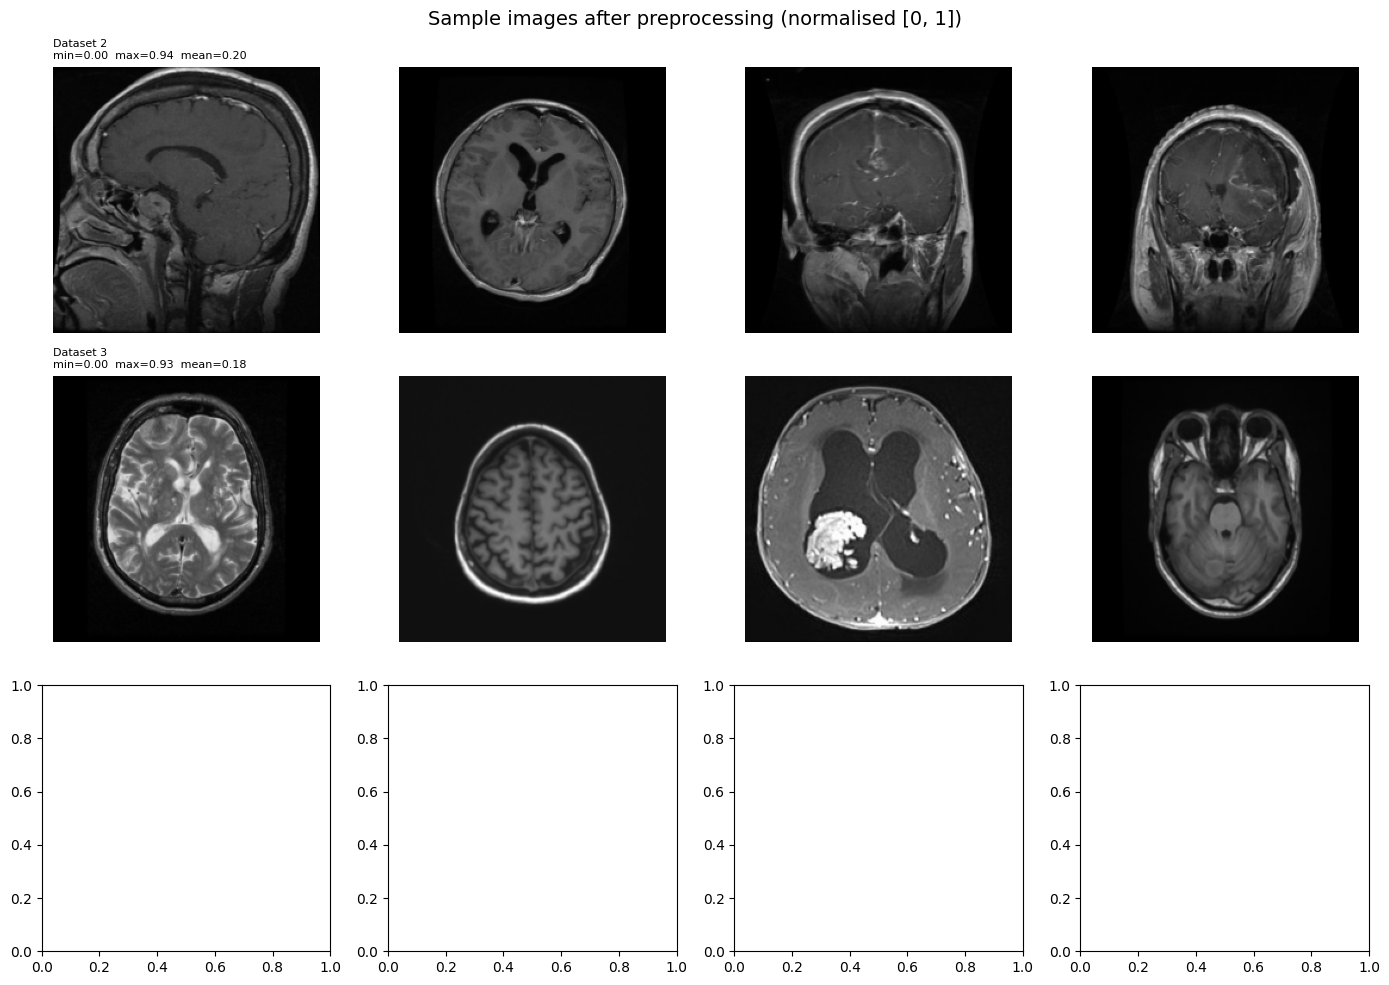

Saved verification.png to brain_mri_preprocessed


In [13]:
fig, axes = plt.subplots(3, 4, figsize=(14, 10))
fig.suptitle('Sample images after preprocessing (normalised [0, 1])', fontsize=14)

for row, (tensors, name) in enumerate([
    (dataset2_train_tensors, 'Dataset 2'),
    (dataset3_train_tensors, 'Dataset 3'),
]):
    indices = torch.randperm(len(tensors))[:4]
    for col, idx in enumerate(indices):
        img = tensors[idx].squeeze(0).numpy()
        axes[row][col].imshow(img, cmap='gray', vmin=0, vmax=1)
        axes[row][col].axis('off')
        if col == 0:
            axes[row][col].set_title(
                f'{name}\nmin={img.min():.2f}  max={img.max():.2f}  mean={img.mean():.2f}',
                fontsize=8, loc='left'
            )

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'verification.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved verification.png to {OUTPUT_DIR}')

## 7. Summary

In [14]:
print(f'All .pt files saved to: {OUTPUT_DIR}\n')
for f in sorted(OUTPUT_DIR.glob('*.pt')):
    data = torch.load(f)
    print(f'  {f.name:<35} {list(data["images"].shape)}  dtype={data["images"].dtype}')

All .pt files saved to: brain_mri_preprocessed

  dataset2_test.pt                    [1600, 1, 224, 224]  dtype=torch.float32
  dataset2_train.pt                   [4900, 1, 224, 224]  dtype=torch.float32
  dataset2_val.pt                     [700, 1, 224, 224]  dtype=torch.float32
  dataset3_test.pt                    [897, 1, 224, 224]  dtype=torch.float32
  dataset3_train.pt                   [3134, 1, 224, 224]  dtype=torch.float32
  dataset3_val.pt                     [447, 1, 224, 224]  dtype=torch.float32
